[*********************100%***********************]  1 of 1 completed


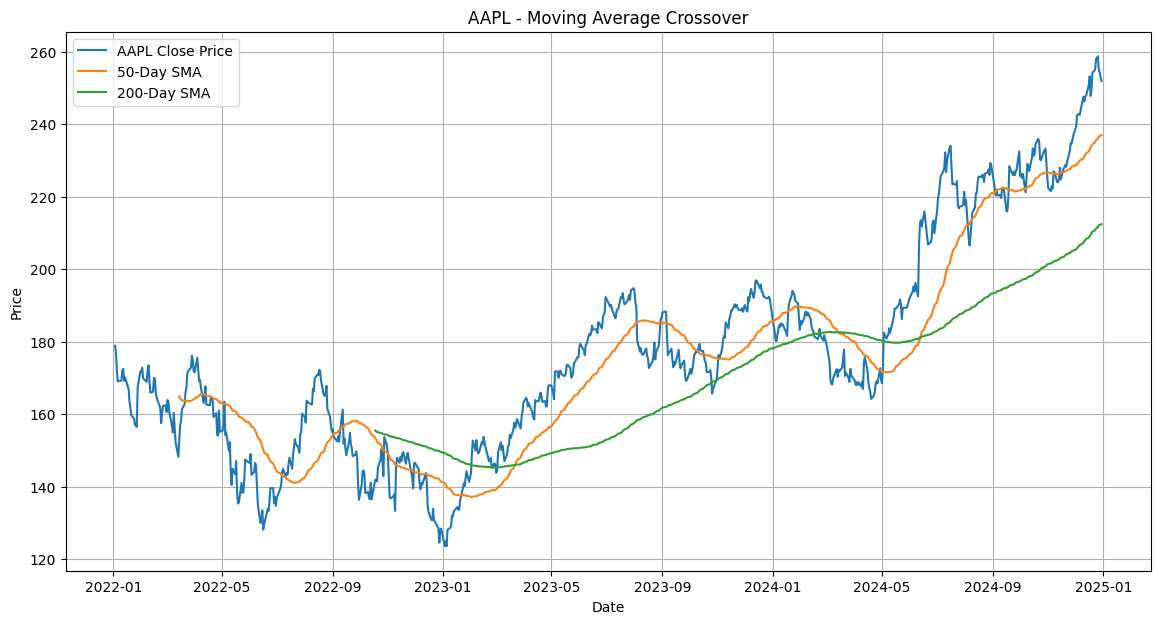

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download historical data
df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")

# Calculate moving averages
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Plot price and moving averages
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='AAPL Close Price')
plt.plot(df['SMA_50'], label='50-Day SMA')
plt.plot(df['SMA_200'], label='200-Day SMA')
plt.title("AAPL - Moving Average Crossover")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_value = []

for i in range(len(df)):
    try:
        price = float(df['Close'].iloc[i])
        sma50 = float(df['SMA_50'].iloc[i])
        sma200 = float(df['SMA_200'].iloc[i])
    except:
        portfolio_value.append(cash + shares * price)
        continue

    # Skip if either SMA is NaN
    if pd.isna(sma50) or pd.isna(sma200):
        portfolio_value.append(cash + shares * price)
        continue

    # BUY condition
    if sma50 > sma200 and shares == 0:
        shares = cash // price
        cash -= shares * price

    # SELL condition
    elif sma50 < sma200 and shares > 0:
        cash += shares * price
        shares = 0

    portfolio_value.append(cash + shares * price)

df['Portfolio Value'] = portfolio_value


/var/folders/0v/3yxbyb2x53ld5v4fl7ss68z80000gn/T/ipykernel_9408/797553524.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(df['Close'].iloc[i])


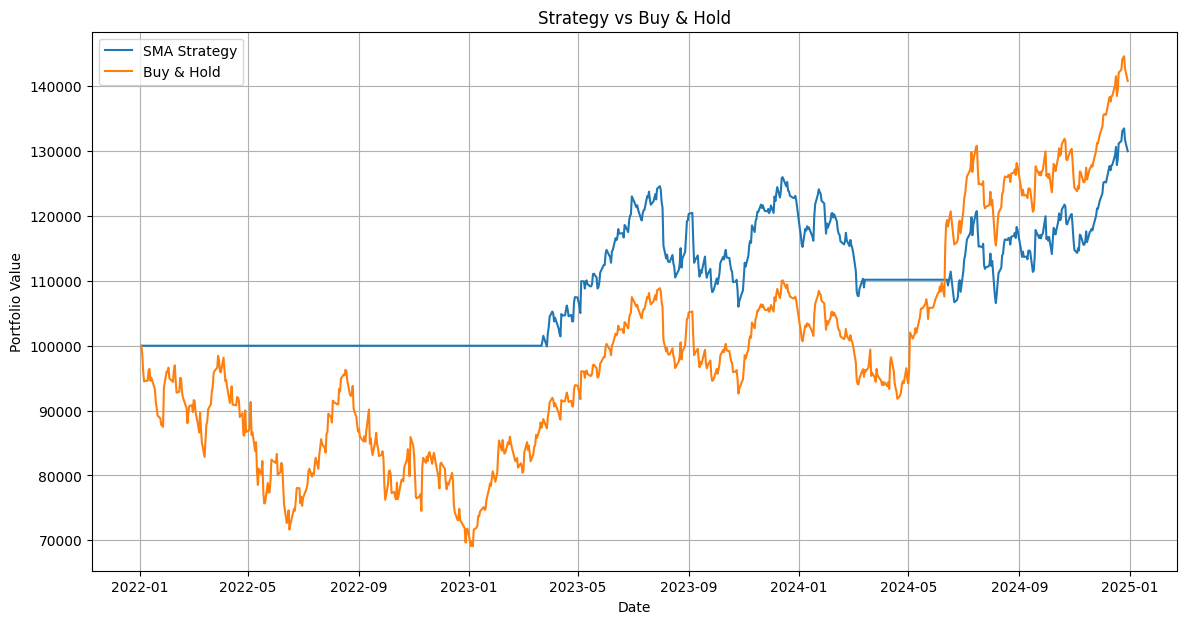

In [18]:
plt.figure(figsize=(14,7))
plt.plot(df['Portfolio Value'], label='SMA Strategy')
plt.plot(df['Close'] / df['Close'].iloc[0] * initial_cash, label='Buy & Hold')
plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()
